In [1]:
# import ecmwf.data as ecdata
from ecmwf.opendata import Client
import pandas as pd
import pygrib as pg
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

### Download latest dataset

In [2]:
parameters = ['100u', '100v', 'ssrd',  '2t']
filename = './weather-data/test.grib2'
client = Client("ecmwf", beta=True)
client.retrieve(
 date=0,
 time=0,
 step=24,
 stream="enfo",
 type=['cf', 'pf'],
 levtype="sfc",
 param=parameters,
 target=filename
)

In [ ]:
grb = pg.open(filename)

Get an overview of available fields (optionally)

In [ ]:
for msg in grb:
    print(msg)  # Print information about the message

### Highest temperature in Spain

In [4]:
msg = grb.select(name='2 metre temperature', level=2)[0]
# 100 metre U wind component
data = msg.values
lats, lons = msg.latlons()
lat_min, lat_max = 37, 41
lon_min, lon_max = -6, -3
# Create a boolean mask to filter the data within the specified region
mask = (lats >= lat_min) & (lats <= lat_max) & (lons >= lon_min) & (lons <= lon_max)

# Apply the mask to the data and coordinates
data_spain = data[mask]
lats_spain = lats[mask]
lons_spain = lons[mask]

df_spain = pd.DataFrame({'temperature': data_spain, 'latitude': lats_spain, 'longitude': lons_spain})
df_spain['temperature'] = (df_spain['temperature'] - 273.15).round()
print(df_spain.head(5))


   temperature  latitude  longitude
0          9.0      41.0      -6.00
1          9.0      41.0      -5.75
2          9.0      41.0      -5.50
3          8.0      41.0      -5.25
4          9.0      41.0      -5.00


In [5]:
highestTemp = df_spain.loc[df_spain['temperature'].idxmax()]
print(highestTemp)

temperature    11.00
latitude       39.75
longitude      -6.00
Name: 65, dtype: float64


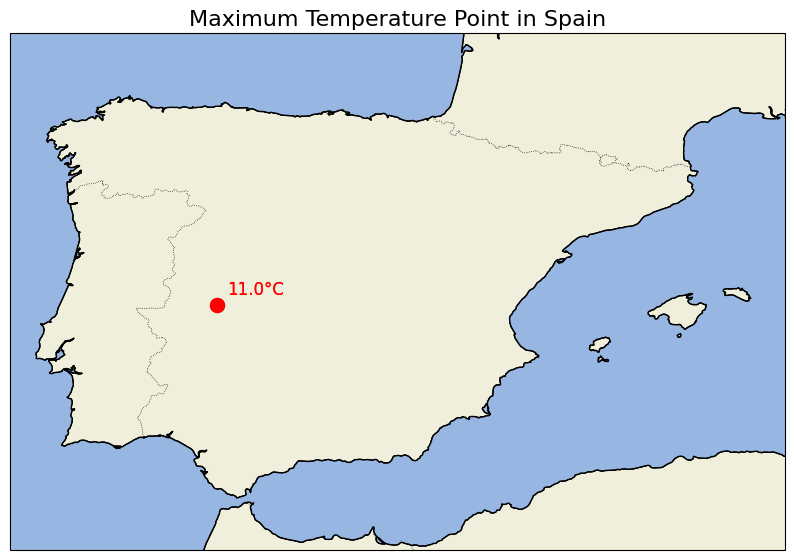

In [7]:
fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())
# Add features (e.g., coastlines, borders)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')  # Remove facecolor
ax.add_feature(cfeature.OCEAN)  # Use default style for ocean

# Plot the point
ax.plot(
    highestTemp["longitude"], highestTemp["latitude"],
    marker='o', markersize=10, color='red', transform=ccrs.PlateCarree()
)
# Annotate the point with temperature
ax.text(
    highestTemp["longitude"] + 0.2, highestTemp["latitude"] + 0.2,
    f"{highestTemp['temperature']}°C",
    color='red', fontsize=12, transform=ccrs.PlateCarree()
)
ax.set_title("Maximum Temperature Point in Spain", fontsize=16)
# Plot the point
ax.plot(
    highestTemp["longitude"], highestTemp["latitude"],
    marker='o', markersize=10, color='red', transform=ccrs.PlateCarree()
)
# Annotate the point with temperature
ax.text(
    highestTemp["longitude"] + 0.2, highestTemp["latitude"] + 0.2,
    f"{highestTemp['temperature']}°C",
    color='red', fontsize=12, transform=ccrs.PlateCarree()
)
ax.set_title("Maximum Temperature Point in Spain", fontsize=16)
plt.show()

### Wind speed calculation

In [19]:
u_wind = grb.select(name='100 metre U wind component', level=100)[0]
v_wind = grb.select(name='100 metre U wind component', level=100)[0]

# Extract data
u_data, lats, lons = u_wind.data()
v_data, _, _ = v_wind.data()

# Calculate wind speed
wind_speed = np.sqrt(u_data**2 + v_data**2)

# Flatten data for DataFrame
flat_lats = lats.flatten()
flat_lons = lons.flatten()
flat_wind_speed = wind_speed.flatten()

# Create a DataFrame
df_wind = pd.DataFrame({
    'Latitude': flat_lats,
    'Longitude': flat_lons,
    'Wind Speed': flat_wind_speed
})

print(df_wind.head())

   Latitude  Longitude  Wind Speed
0      90.0    -180.00    3.562724
1      90.0    -179.75    3.562724
2      90.0    -179.50    3.562724
3      90.0    -179.25    3.562724
4      90.0    -179.00    3.562724


In [20]:
# Calculate the 95th percentile value
percentile_95 = df_wind['Wind Speed'].quantile(0.95)

# Filter the DataFrame for wind speeds in the top 5%
top_5_percent = df_wind[df_wind['Wind Speed'] >= percentile_95]

# Display the filtered data
print(f"95th Percentile Wind Speed: {percentile_95}")
print(top_5_percent.head())

95th Percentile Wind Speed: 19.078503996445484
       Latitude  Longitude  Wind Speed
68400     78.25       0.00   19.197276
68401     78.25       0.25   19.332620
68402     78.25       0.50   19.561878
68403     78.25       0.75   19.694460
68404     78.25       1.00   19.930623


#### Plot top 5% percentile

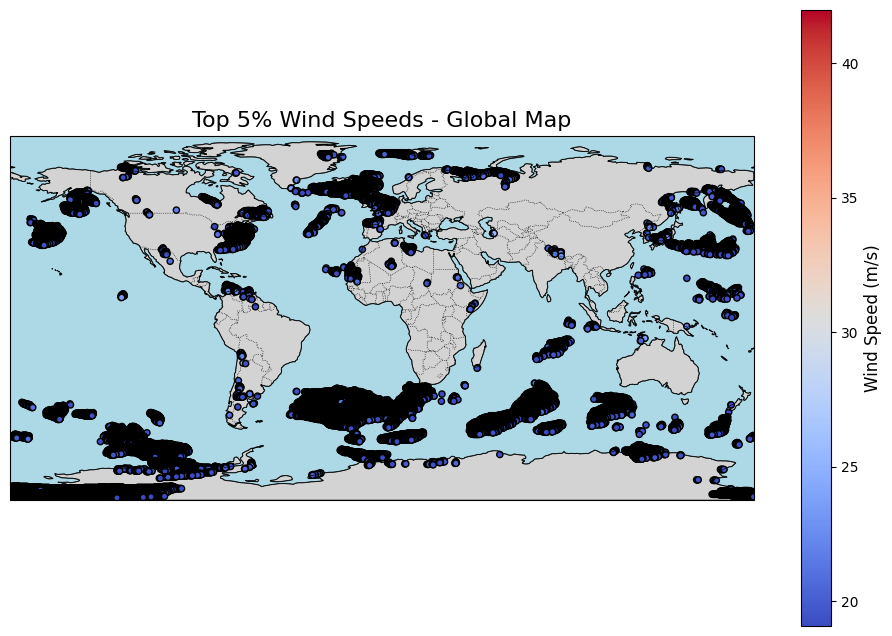

In [22]:
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

scatter = ax.scatter(
    top_5_percent['Longitude'], top_5_percent['Latitude'],
    c=top_5_percent['Wind Speed'], cmap='coolwarm', s=20, edgecolor='k',
    transform=ccrs.PlateCarree()
)

# Add a colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label('Wind Speed (m/s)', fontsize=12)

# Add a title
ax.set_title("Top 5% Wind Speeds - Global Map", fontsize=16)

# Show the plot
plt.show()